# Ανιχνευτές γωνιών

##Harris Corner Detector

[Harris, Christopher G. and Mike Stephens. “A Combined Corner and Edge Detector.” Alvey Vision Conference (1988)](http://www.bmva.org/bmvc/1988/avc-88-023.pdf)

Μια γωνία είναι ένα σημείο του οποίου η τοπική γειτονιά βρίσκεται σε δύο κυρίαρχες και διαφορετικές ακμές. Οι γωνίες είναι τα σημαντικά χαρακτηριστικά της εικόνας και γενικά ορίζονται ως σημεία ενδιαφέροντος που είναι αναλλοίωτα στη μετατόπιση, την περιστροφή και το φωτισμό.

![alt text](https://drive.google.com/uc?id=1nc3RAUAjGlzmy2yHXzfyiiHvmlwPWTX5)

Eάν πάρουμε την επίπεδη περιοχή της εικόνας (δείτε την προηγούμενη εικόνα) τότε δεν παρατηρείται αλλαγή κλίσης προς οποιαδήποτε κατεύθυνση. Ομοίως, στην περιοχή των ακμών, δεν παρατηρείται αλλαγή κλίσης κατά την κατεύθυνση της ακμής. Στη γωνιακή περιοχή παρατηρούμε μια σημαντική αλλαγή κλίσης προς όλες τις κατευθύνσεις.

###Ανίχνευση γωνίας

Η ιδέα είναι να εξετάσουμε ένα μικρό παράθυρο γύρω από κάθε pixel p της εικόνας. Θέλουμε να αναγνωρίσουμε όλα αυτά τα παράθυρα που είναι μοναδικά. Η μοναδικότητα μπορεί να μετρηθεί μετατοπίζοντας ελάχιστα κάθε παράθυρο προς μια δεδομένη κατεύθυνση και μετρώντας το ποσό της αλλαγής που συμβαίνει στις τιμές των pixel.

Για να μετρήσουμε αυτήν την αλλαγή, θα πάρουμε την αθροιστική διαφορά (SSD) των τιμών pixel πριν και μετά τη μετατόπιση και θα προσδιορίζουμε τα παράθυρα, που όταν εφαρμόσουμε στα pixels, το SSD θα είναι μεγάλο για μετατοπίσεις και προς τις 8 κατευθύνσεις.

Ας ορίσουμε τη **συνάρτηση αλλαγής $E(u,v)$** ως το άθροισμα όλων των αθροιστικών τετραγώνων διαφορών (SSD), όπου $u, v$ είναι οι μικρές μετατοπίσεις, $x, y$ είναι οι συντεταγμένες του pixel και $I$ είναι η τιμή έντασης του pixel.

$E(u,v)=\sum_{x,y}w(x,y)[I(x+u,y+v)-I(x,y)]^2$

όπου $w(x,y)=exp(-\frac{x^2+y^2}{2σ^2})$ η Gaussian συνάρτηση.


Τα pixels που έχουν τιμές $E(u, v)$ μεγαλύτερες από ένα καθορισμένο κατώφλι αποτελούν τα χαρακτηριστικά της εικόνας που αναζητούμε, δηλαδή τις γωνίες.

Οπότε, πρέπει να μεγιστοποιήσουμε τη συνάρτηση $Ε(u,v)$ για να εντοπίσουμε τις γωνίες πάνω στην εικόνα. Αυτό συνεπάγεται ότι θα πρέπει να μεγιστοποιήσουμε το δεύτερο όρο της συνάρτησης. Εφαρμόζοντας ανάπτυγμα Taylor και μετά από μαθηματικές πράξεις, καταλήγουμε στην εξίσωση:

$E(u,v)\approx\begin{bmatrix}u&v\end{bmatrix}\begin{pmatrix}\sum\begin{bmatrix}
    I_x^2 & I_xI_y \\
    I_xI_y & I_y^2
 \end{bmatrix}\end{pmatrix}\begin{bmatrix}u\\v\end{bmatrix}\quad $ ή $\quad E(u,v)\approx\begin{bmatrix}u&v\end{bmatrix}Μ\begin{bmatrix}u\\v\end{bmatrix}$


Με την επίλυση των ιδιοδιανυσμάτων του M (auto-correlation matrix), μπορούμε να λάβουμε τόσο τις μεγαλύτερες όσο και για τις μικρότερες αυξήσεις στο SSD.
(Οι ιδιοτιμές μας δείχνουν το πλάτος ενώ τα ιδιοδιανύσματα την κατεύθυνση)

<img src="https://drive.google.com/uc?id=1ytW5hTP5Ofqm2EFovUbJ1APexdIXA-2e" width="60%">

Μια συνάρτηση βαθμολόγησης (σκορ) R, υπολογίζεται για κάθε παράθυρο:

$$R=detΜ-k(traceΜ)^2$$
$$detM=λ_1λ_2$$
$$traceM=λ_1+λ_2$$

όπου $λ_1$ και $λ_2$ είναι οι ιδιοτιμές του M και $k\in [0.04-0.06]$.

Oι τιμές των ιδιοτιμών αποφασίζουν εάν μια περιοχή είναι μια γωνία, ακμή ή επίπεδη όπως φαίνεται στην ακόλουθη εικόνα.

<img src="https://drive.google.com/uc?id=1wWwhq6gfwLPVYXc-ayv8UNhAsTk6t__0" width="60%">


*Βήματα Αλγορίθμου Harris Corner Detector*


1. Εφαρμογή Gaussian φίλτρου για εξομάλυνση θορύβου στην αρχική grayscale εικόνα,  
2. Εφαρμογή Sobel φίλτρου για να βρούμε τις κλίσεις (g(x,y)) για κάθε pixel στην grayscale εικόνα,
3. Σε κάθε pixel p της grayscale εικόνας, υπολογίσουμε την τιμή $R$
4. Κατωφλίωση των τιμών $R$ του κάθε pixel,
5. Εξάλειψη μη μεγίστων (Non-maxima suppression) και εύρεση πραγματικών γωνιών.


<img src="https://drive.google.com/uc?id=1Ylqlr1fmGtfc0u3dGw4wtM9gFE0EJZg1" width="60%">


##Shi-Tomasi Corner Detector

[Jianbo Shi and Tomasi, "Good features to track," IEEE CVPR, 1994](https://https://ieeexplore.ieee.org/abstract/document/323794)

Το 1994, οι J. Shi και C. Tomasi έκαναν μια μικρή τροποποίηση για την ανίχνευση ακμών παρουσιάζοντας καλύτερα αποτελέσματα σε σύγκριση με τον Harris Corner Detector.

**Συνάρτηση βαθμολόγησης**

- Harris corner detector: $R =λ_1λ_2-k(λ_1+λ_2)^2$

- Shi-Tomasi corner detector: $R = min (λ1, λ2)$

![](https://drive.google.com/uc?id=1XpQgdhOWPOboCSXWpeOL3P9QKFXgBaqQ)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.feature import corner_harris, corner_subpix, corner_peaks,corner_shi_tomasi
from skimage.transform import warp, AffineTransform
from skimage.draw import ellipse


# Read in the image
image = data.checkerboard()

Εφαρμογή αλγορίθμου για του Corner Detectors Harris και Shi-Tomasi



In [ ]:
#corner_harris
# skimage.feature.corner_harris(image, method='k', k=0.05, eps=1e-06, sigma=1)
# method{‘k’, ‘eps’}, optional  Method to compute the response image from the auto-correlation matrix.
# k float, optional Sensitivity factor to separate corners from edges, typically in range [0, 0.2]. Small values of k result in detection of sharp corners.
# eps float, optional Normalisation factor (Noble’s corner measure).
# sigma float, optional Standard deviation used for the Gaussian kernel, which is used as weighting function for the auto-correlation matrix.
# Returns responsend array Harris response image.

#corner_peaks
#skimage.feature.corner_peaks(image, min_distance=1, threshold_abs=None, threshold_rel=None, exclude_border=True, indices=True, num_peaks=inf, footprint=None, labels=None, *, num_peaks_per_label=inf)[source]
# Find corners in corner measure response image.
# This differs from skimage.feature.peak_local_max in that it suppresses multiple connected peaks with the same accumulator value.

#corner_subpix
#skimage.feature.corner_subpix(image, corners, window_size=11, alpha=0.99)
#Determine subpixel position of corners.
# A statistical test decides whether the corner is defined as the intersection of two edges or a single peak.
# Depending on the classification result, the subpixel corner location is determined based on the local covariance of the grey-values.
# If the significance level for either statistical test is not sufficient, the corner cannot be classified, and the output subpixel position is set to NaN.

# corners(N, 2) ndarray Corner coordinates (row, col).
# window_sizeint, optional Search window size for subpixel estimation.
# alphafloat, optional Significance level for corner classification.
#Returns
#positions(N, 2) ndarray Subpixel corner positions. NaN for “not classified” corners.

#Harris Corner
coords = corner_peaks(corner_harris(image), min_distance=1)
coords_subpix = corner_subpix(image, coords, window_size=13)

# Shi tomasi corner
coordshi = corner_peaks(corner_shi_tomasi(image), min_distance=1)
coords_subpixshi = corner_subpix(image, coordshi, window_size=13)

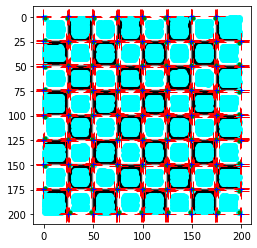

In [ ]:
fig, ax = plt.subplots()

ax.imshow(image, cmap=plt.cm.gray)

# Harris Corner
ax.plot(coords[:, 1], coords[:, 0], color='cyan', marker='o', linestyle='None', markersize=6)
ax.plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=15)

# Shi tomasi corner
ax.plot(coordshi[:, 1], coordshi[:, 0], color='green', marker='o', linestyle='None', markersize=3)
ax.plot(coords_subpixshi[:, 1], coords_subpixshi[:, 0], '+b', markersize=5)

plt.show()